In [3]:
import pandas as pd
import re
import numpy as np
from io import StringIO   # <-- use isto
import matplotlib.pyplot as plt

# Tratamento de Dados

In [5]:
arquivo = "vib_mode.txt"

with open(arquivo, "r") as f:
    linhas = f.readlines()

# --------------------
# 1) Parte inicial (159 linhas)
# --------------------

linhas_159 = linhas[:159]

header = re.split(r"\s+", linhas[0].strip())
header = [h for h in header if h != ""]

df = pd.read_csv(
    StringIO("".join(linhas_159)),
    delim_whitespace=True,
    names=header,
    skiprows=1
)

# --------------------
# 2) Blocos seguintes
# --------------------

blocos = []
i = 159

num_regex = r"^\s*\d+(\s+\d+)*\s*$"

while i < len(linhas):

    # Linha com números das colunas
    col_header_line = linhas[i].strip()
    novas_cols = re.split(r"\s+", col_header_line)
    novas_cols = [c for c in novas_cols if c != ""]
    i += 1

    bloco_linhas = []

    # Acumular linhas do bloco
    while i < len(linhas) and not re.match(num_regex, linhas[i]):
        bloco_linhas.append(linhas[i])
        i += 1

    # Se não houver linhas, pula
    if len(bloco_linhas) == 0:
        continue

    # ----------------------------
    # Detectar número real de colunas no bloco
    # ----------------------------
    primeira_linha = bloco_linhas[0].strip()
    ncols = len(re.split(r"\s+", primeira_linha))

    # criar nomes para todas as colunas
    # primeira é índice, outras são novas_cols (até onde existirem)
    nomes = ["idx"] + novas_cols + [f"extra_{k}" for k in range(len(novas_cols)+1, ncols)]

    df_bloco = pd.read_csv(
        StringIO("".join(bloco_linhas)),
        delim_whitespace=True,
        names=nomes
    )

    df_bloco = df_bloco.drop(columns=["idx"])
    blocos.append(df_bloco)

# --------------------
# 3) Concatenar
# --------------------

for b in blocos:
    df = pd.concat([df, b], axis=1)

C:\Users\55219\AppData\Local\Temp\ipykernel_19388\891586951.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\55219\AppData\Local\Temp\ipykernel_19388\891586951.py:60: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_bloco = pd.read_csv(
C:\Users\55219\AppData\Local\Temp\ipykernel_19388\891586951.py:60: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_bloco = pd.read_csv(
C:\Users\55219\AppData\Local\Temp\ipykernel_19388\891586951.py:60: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_bloco = pd.read_csv(
C:\Users\55219\AppData\Local\Temp\ipykernel_19388\891586951.py:60:

In [13]:
def renomear_index_por_atom(df, lista_atomica):
    """
    df: DataFrame final já criado (159 linhas)
    lista_atomica: lista de strings com linhas contendo símbolo, massa e coordenadas
    """
    # Extrair apenas o símbolo atômico de cada linha
    simbolos = [linha.split()[0] for linha in lista_atomica]

    novo_index = []
    contadores = {}  # exemplo: {"C":1, "H":1, "O":1}

    for simbolo in simbolos:
        if simbolo not in contadores:
            contadores[simbolo] = 1

        nome = f"{simbolo}{contadores[simbolo]}"

        # Cada átomo corresponde a 3 linhas do DataFrame
        novo_index.extend([nome, nome, nome])

        contadores[simbolo] += 1

    # Aplicar ao DataFrame
    df.index = novo_index
    return df

In [9]:
lista_atomica = [
    "C     12.01100      2.973681262488     4.433588370412     2.907118610020",
    "H      1.00800      4.438636336018     4.096343702770     1.517445859169",
    "C     12.01100      3.349033508860     6.099156797171     4.891544492879",
    "H      1.00800      5.131098413428     7.086116842468     5.064323110607",
    "C     12.01100      1.416857216363     6.449225669952     6.624318556197",
    "C     12.01100     -0.813975864176     5.124343791395     6.318412534880",
    "H      1.00800     -2.365529249717     5.331895928350     7.636251783508",
    "C     12.01100     -1.055044182539     3.481449391209     4.284769463574",
    "C     12.01100      3.266272124495     1.971863051620    -3.783046495634",
    "H      1.00800      4.907273574747     2.026676068881    -5.014281018673",
    "C     12.01100      4.831788124954    -1.119661772077    -0.829913406291",
    "C     12.01100      3.846390638596    -2.447188703574     1.316881780311",
    "C     12.01100      5.462370990947    -4.238195739750     2.491351057306",
    "H      1.00800      4.747199791327    -5.269638064674     4.106833445582",
    "C     12.01100      7.851883633041    -4.637153537204     1.595907434401",
    "H      1.00800      9.102047340018    -5.993519160081     2.477383147950",
    "C     12.01100      8.746721637778    -3.282724389728    -0.503414874689",
    "C     12.01100      7.254719452136    -1.534940410352    -1.725685221768",
    "H      1.00800      8.017824757749    -0.534524849040    -3.337799704551",
    "N     14.00700      0.838960374938     3.157614431734     2.592756991919",
    "N     14.00700      3.089974559314     0.555510163282    -1.806299315458",
    "N     14.00700     11.286010832116    -3.712345283981    -1.402352424528",
    "O     15.99900      1.613994718307    -1.984883835774     2.086583982029",
    "O     15.99900     12.567311545396    -5.270856575112    -0.299666606102",
    "O     15.99900     12.012733201687    -2.488714404555    -3.213463490204",
    "Fe    55.85000     -0.000472963401     0.629386072598    -0.000972666525",
    "H      1.00800      1.650060008965     7.734485669450     8.200356266721",
    "C     12.01100     -3.267318030759     1.973957919478     3.780512658569",
    "C     12.01100      1.055148669305     3.481283892318    -4.286366438234",
    "O     15.99900     -1.616784434483    -1.982088788807    -2.090314182519",
    "N     14.00700     -3.091362800163     0.557457126812     1.803858113442",
    "N     14.00700     -0.838615628669     3.158823341921    -2.593847947989",
    "H      1.00800     -4.909287838513     2.031332675085     5.010324666427",
    "C     12.01100      0.814921445521     5.124595367269    -6.319793097029",
    "C     12.01100     -3.848860557309    -2.444575480131    -1.319773944667",
    "C     12.01100     -4.833648990177    -1.117175073734     0.827387546711",
    "C     12.01100     -2.972199107889     4.436930953642    -2.907279116830",
    "C     12.01100     -1.414830760820     6.451482530131    -6.624861565233",
    "H      1.00800      2.366419281683     5.331231960092    -7.637839365198",
    "C     12.01100     -5.464525798432    -4.236811063559    -2.492813647982",
    "C     12.01100     -7.255025921827    -1.535294151382     1.726065870990",
    "H      1.00800     -4.436950260627     4.101044704909    -1.517076338492",
    "C     12.01100     -3.346722678228     6.102988515578    -4.891451614673",
    "H      1.00800     -1.647424185631     7.737057510138    -8.200735338861",
    "H      1.00800     -4.749838217883    -5.268014797907    -4.108663992441",
    "C     12.01100     -7.852645929102    -4.638213469171    -1.594761752587",
    "C     12.01100     -8.746555788440    -3.284678546416     0.505536300208",
    "H      1.00800     -8.017331099830    -0.535753405284     3.339092797671",
    "H      1.00800     -5.127941625071     7.091606647039    -5.063513305887",
    "H      1.00800     -9.102286432116    -5.996055844799    -2.474718328155",
    "N     14.00700    -11.284236490734    -3.717204290656     1.407618444445",
    "O     15.99900    -12.565407060232    -5.276509904686     0.305862900654",
    "O     15.99900    -12.009912115184    -2.494980093975     3.220062700617"
]

In [15]:
df = renomear_index_por_atom(df, lista_atomica)

In [17]:
df

,0,1,2,3,4,5,6,7,8,9,...,149,150,151,152,153,154,155,156,157,158
C1,0.0,0.0,0.0,0.0,0.0,0.0,-0.052786,0.044728,-0.009205,0.025193,...,0.000049,0.000236,-0.011606,6.520110e-03,1.186557e-04,0.000055,-0.002823,1.990622e-02,-1.113432e-05,3.054932e-05
C1,0.0,0.0,0.0,0.0,0.0,0.0,0.098106,-0.083154,-0.017763,-0.074919,...,-0.000015,-0.000066,0.003293,-1.841396e-03,-1.047510e-05,-0.000017,0.000992,-7.123257e-03,-9.162994e-06,-1.268613e-05
C1,0.0,0.0,0.0,0.0,0.0,0.0,0.009116,-0.064280,-0.068141,0.021328,...,-0.000055,-0.000238,0.011877,-6.655379e-03,-9.006973e-05,-0.000058,0.003143,-2.234100e-02,-5.316683e-06,-3.616441e-05
H1,0.0,0.0,0.0,0.0,0.0,0.0,-0.034659,0.026487,0.010061,0.025989,...,-0.000570,-0.002835,0.133874,-7.505278e-02,-1.555465e-03,-0.000716,0.032494,-2.299466e-01,4.382230e-05,-3.980106e-04
H1,0.0,0.0,0.0,0.0,0.0,0.0,0.093449,-0.082822,-0.076687,-0.085215,...,0.000099,0.000679,-0.032043,1.801121e-02,3.468838e-04,0.000175,-0.008064,5.720631e-02,1.948100e-07,9.541356e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
O5,0.0,0.0,0.0,0.0,0.0,0.0,-0.222030,-0.101211,0.045575,-0.172634,...,-0.000128,-0.000094,0.000002,1.905067e-06,5.549022e-07,0.000003,0.000003,4.356349e-06,-3.484359e-04,9.665141e-06
O5,0.0,0.0,0.0,0.0,0.0,0.0,0.069332,0.200317,0.011819,0.126699,...,-0.000197,-0.000148,0.000001,7.786528e-07,-2.279998e-07,0.000091,0.000002,2.354273e-06,-5.335980e-04,1.558064e-05
O6,0.0,0.0,0.0,0.0,0.0,0.0,0.076570,0.071721,-0.047498,-0.109335,...,-0.000019,-0.000013,0.000012,-3.698949e-06,-7.873447e-07,0.000440,0.000007,3.612864e-06,-1.672105e-04,3.816006e-06
O6,0.0,0.0,0.0,0.0,0.0,0.0,-0.188262,-0.125040,0.083447,0.187194,...,-0.000011,-0.000008,0.000004,-7.774231e-07,-3.081083e-06,0.000468,0.000002,-1.634482e-08,-5.217301e-05,1.761143e-06


In [19]:
df.to_csv('df.csv')

# Plot

In [21]:
df

,0,1,2,3,4,5,6,7,8,9,...,149,150,151,152,153,154,155,156,157,158
C1,0.0,0.0,0.0,0.0,0.0,0.0,-0.052786,0.044728,-0.009205,0.025193,...,0.000049,0.000236,-0.011606,6.520110e-03,1.186557e-04,0.000055,-0.002823,1.990622e-02,-1.113432e-05,3.054932e-05
C1,0.0,0.0,0.0,0.0,0.0,0.0,0.098106,-0.083154,-0.017763,-0.074919,...,-0.000015,-0.000066,0.003293,-1.841396e-03,-1.047510e-05,-0.000017,0.000992,-7.123257e-03,-9.162994e-06,-1.268613e-05
C1,0.0,0.0,0.0,0.0,0.0,0.0,0.009116,-0.064280,-0.068141,0.021328,...,-0.000055,-0.000238,0.011877,-6.655379e-03,-9.006973e-05,-0.000058,0.003143,-2.234100e-02,-5.316683e-06,-3.616441e-05
H1,0.0,0.0,0.0,0.0,0.0,0.0,-0.034659,0.026487,0.010061,0.025989,...,-0.000570,-0.002835,0.133874,-7.505278e-02,-1.555465e-03,-0.000716,0.032494,-2.299466e-01,4.382230e-05,-3.980106e-04
H1,0.0,0.0,0.0,0.0,0.0,0.0,0.093449,-0.082822,-0.076687,-0.085215,...,0.000099,0.000679,-0.032043,1.801121e-02,3.468838e-04,0.000175,-0.008064,5.720631e-02,1.948100e-07,9.541356e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
O5,0.0,0.0,0.0,0.0,0.0,0.0,-0.222030,-0.101211,0.045575,-0.172634,...,-0.000128,-0.000094,0.000002,1.905067e-06,5.549022e-07,0.000003,0.000003,4.356349e-06,-3.484359e-04,9.665141e-06
O5,0.0,0.0,0.0,0.0,0.0,0.0,0.069332,0.200317,0.011819,0.126699,...,-0.000197,-0.000148,0.000001,7.786528e-07,-2.279998e-07,0.000091,0.000002,2.354273e-06,-5.335980e-04,1.558064e-05
O6,0.0,0.0,0.0,0.0,0.0,0.0,0.076570,0.071721,-0.047498,-0.109335,...,-0.000019,-0.000013,0.000012,-3.698949e-06,-7.873447e-07,0.000440,0.000007,3.612864e-06,-1.672105e-04,3.816006e-06
O6,0.0,0.0,0.0,0.0,0.0,0.0,-0.188262,-0.125040,0.083447,0.187194,...,-0.000011,-0.000008,0.000004,-7.774231e-07,-3.081083e-06,0.000468,0.000002,-1.634482e-08,-5.217301e-05,1.761143e-06


In [23]:
atomos = [('O1',15.99900),('O4',15.99900),('N1',14.00700),('N2',14.00700),('N4',14.00700),('N5',14.00700),('Fe1',55.85000)]
#atomos = [('O1',1),('O2',1),('N3',1),('N4',1),('N5',1),('N6',1),('Fe1',1)]
atomos_tot = [
    ("C1", 12.01100),
    ("H1", 1.00800),
    ("C2", 12.01100),
    ("H2", 1.00800),
    ("C3", 12.01100),
    ("C4", 12.01100),
    ("H3", 1.00800),
    ("C5", 12.01100),
    ("C6", 12.01100),
    ("H4", 1.00800),
    ("C7", 12.01100),
    ("C8", 12.01100),
    ("C9", 12.01100),
    ("H5", 1.00800),
    ("C10", 12.01100),
    ("H6", 1.00800),
    ("C11", 12.01100),
    ("C12", 12.01100),
    ("H7", 1.00800),
    ("N1", 14.00700),
    ("N2", 14.00700),
    ("N3", 14.00700),
    ("O1", 15.99900),
    ("O2", 15.99900),
    ("O3", 15.99900),
    ("Fe1", 55.85000),
    ("H8", 1.00800),
    ("C13", 12.01100),
    ("C14", 12.01100),
    ("O4", 15.99900),
    ("N4", 14.00700),
    ("N5", 14.00700),
    ("H9", 1.00800),
    ("C15", 12.01100),
    ("C16", 12.01100),
    ("C17", 12.01100),
    ("C18", 12.01100),
    ("C19", 12.01100),
    ("H10", 1.00800),
    ("C20", 12.01100),
    ("C21", 12.01100),
    ("H11", 1.00800),
    ("C22", 12.01100),
    ("H12", 1.00800),
    ("H13", 1.00800),
    ("C23", 12.01100),
    ("C24", 12.01100),
    ("H14", 1.00800),
    ("H15", 1.00800),
    ("H16", 1.00800),
    ("N6", 14.00700),
    ("O5", 15.99900),
    ("O6", 15.99900)
]


col = np.arange(0,159)

contr_atom = []
contr_atom_total = []

for j in col:
    soma_modo = 0.0
    soma_modo_total = 0
    for at in atomos:
        val = at[1]*((df.loc[str(at[0])]**2)[str(j)]).sum()
        soma_modo += val
        #print(at[0],at[1],str(j))
    for at in atomos_tot:
        val_tot = at[1]*((df.loc[str(at[0])]**2)[str(j)]).sum()
        soma_modo_total += val_tot
        #print(at[0],at[1],str(j))
    contr_atom.append(soma_modo)
    contr_atom_total.append(soma_modo_total)

#FALTA MULTIPLICAR O LOOP PELA MASSA ALAN. TERMINAR QDO VOLTAR O BDJ

In [25]:
Oct = np.array(contr_atom[6:])
Tot = np.array(contr_atom_total[6:])

Contr_oct = Oct/Tot

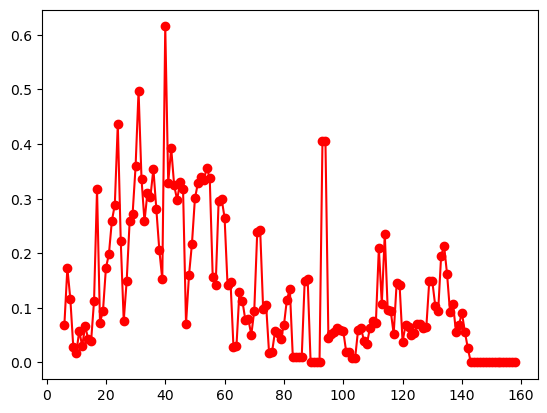

In [67]:
plt.plot(col[6:], Contr_oct,marker='o',color='red')
plt.show()

In [39]:
Contr_oct_df = pd.read_csv("Oct_Contri.csv")

In [41]:
Contr_oct_df

,index,valor,array
0,6,16.769442,0.069548
1,7,24.787586,0.172795
2,8,38.390674,0.116668
3,9,50.330764,0.027723
4,10,51.146710,0.017137
...,...,...,...
148,154,3229.819330,0.000004
149,155,3234.134543,0.000009
150,156,3234.160106,0.000009
151,157,3238.127558,0.000002


In [43]:
Contr_oct_df.sort_values(by=['array'],ascending=False)[:15]

,index,valor,array
34,40,442.668948,0.615414
25,31,328.892827,0.497352
18,24,217.818345,0.436885
87,93,1043.641099,0.406211
88,94,1046.813843,0.404808
36,42,476.561135,0.392718
24,30,313.729166,0.359218
48,54,591.548333,0.357008
30,36,390.375241,0.354482
46,52,585.989350,0.340163
